In [1]:
!pip install mne -q

In [2]:
# Install MNE if not already installed (uncomment the line below if needed)
# !pip install mne -q

import mne
import matplotlib.pyplot as plt
import os

# Use the direct raw link provided by the user
data_link_source = 'https://raw.githubusercontent.com/MyProfile-projects/Wavelet.-P--R--and-T-peaks-detection/refs/heads/main/dataset_4_test/01_ГУСА.edf'

# Define the local path where the EDF file will be stored
# We will use the last part of the URL as the local filename.
# If it doesn't already have an .edf extension, we'll add one for MNE compatibility.
local_file_name_from_url = data_link_source.split('/')[-1]
if not local_file_name_from_url.lower().endswith('.edf'):
    local_file_name = local_file_name_from_url + '.edf'
else:
    local_file_name = local_file_name_from_url

edf_file_path = os.path.join('/tmp', local_file_name)

# Use !wget to download the file
print(f"Attempting to download {data_link_source} to {edf_file_path} using wget...")

# Delete existing file to ensure a fresh download, especially if previous attempts were corrupted
if os.path.exists(edf_file_path):
    print(f"Deleting existing file at {edf_file_path} to ensure fresh download.")
    os.remove(edf_file_path)

# Execute wget command silently (-q) and force output to specific filename (-O)
!wget -q -O {edf_file_path} {data_link_source}

# Verify if download was successful (check file existence and size)
MIN_EDF_SIZE_BYTES = 256 # A typical EDF header is 256 bytes

if os.path.exists(edf_file_path):
    file_size = os.path.getsize(edf_file_path)
    if file_size < MIN_EDF_SIZE_BYTES:
        print(f"Error: Downloaded file is too small ({file_size} bytes). This likely indicates the URL is incorrect (e.g., a 404 Not Found error) or the file is corrupted.")
        edf_file_path = None # Mark as invalid
    else:
        print(f"Download successful. File size: {file_size} bytes.")
else:
    print("Error: Download failed or file was not created by wget. Check the URL and network connection.")
    edf_file_path = None


# Initialize raw to None to prevent NameError if loading fails
raw = None

if edf_file_path:
    try:
        # Load the EDF file
        print(f"Loading EDF file from {edf_file_path} with MNE...")
        raw = mne.io.read_raw_edf(edf_file_path, preload=True)

        # Display basic information about the loaded data
        display(raw.info)

        # Filter out 'bad' channels if any
        initial_channel_count = len(raw.ch_names)
        raw.info['bads'] = [ch for ch in raw.ch_names if 'bad' in ch.lower()]
        if raw.info['bads']:
            print(f"Excluding bad channels: {raw.info['bads']}")
            raw.pick_channels([ch for ch in raw.ch_names if ch not in raw.info['bads']])

        print(f"Number of channels after filtering: {len(raw.ch_names)} (from {initial_channel_count})")

    except Exception as e:
        print(f"Error loading EDF file with MNE: {e}")
        print("The file might be genuinely corrupted or malformed, or MNE has trouble parsing it.")
        raw = None # Ensure raw is None if loading fails

# If raw is still None, indicate that processing cannot proceed
if raw is None:
    print("Cannot proceed with EDF data processing as 'raw' object is not defined.")

Attempting to download https://raw.githubusercontent.com/MyProfile-projects/Wavelet.-P--R--and-T-peaks-detection/refs/heads/main/dataset_4_test/01_ГУСА.edf to /tmp/01_ГУСА.edf using wget...
Deleting existing file at /tmp/01_ГУСА.edf to ensure fresh download.
Download successful. File size: 3997024 bytes.
Loading EDF file from /tmp/01_ГУСА.edf with MNE...
Extracting EDF parameters from /tmp/01_ГУСА.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 665999  =      0.000 ...  3329.995 secs...


<Info | 8 non-empty values
 bads: []
 ch_names: ECG V2-Ref, ECG V5-Ref, ECG avF-Ref
 chs: 3 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: 2017-11-14 11:30:20 UTC
 nchan: 3
 projs: []
 sfreq: 200.0 Hz
 subject_info: <subject_info | his_id: >
>

Number of channels after filtering: 3 (from 3)


Found ECG channels: ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
Using matplotlib as 2D backend.


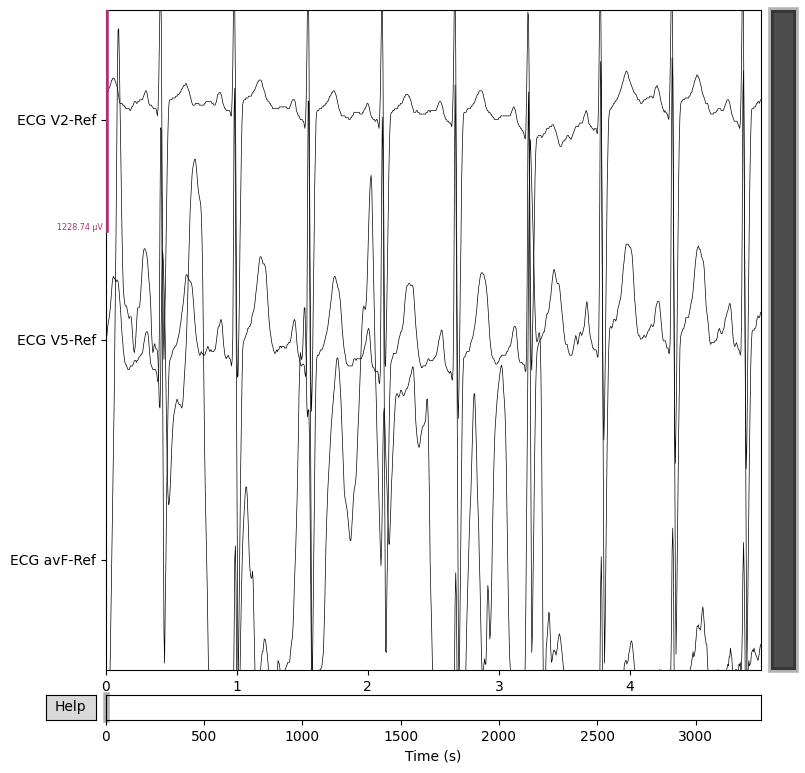

<Figure size 640x480 with 0 Axes>

In [3]:
# Find ECG channels (assuming channels containing 'ECG' in their names)
ecg_channels = [ch for ch in raw.ch_names if 'ECG' in ch.upper()]

if ecg_channels:
    print(f"Found ECG channels: {ecg_channels}")
    # Plot ECG channels
    # We'll plot a segment of the data to make it manageable
    # Adjust duration and n_channels as needed
    raw.plot(duration=5, start=0, n_channels=len(ecg_channels), scalings='auto', picks=ecg_channels, show_scrollbars=True)
    plt.tight_layout()
    plt.show()
else:
    print("No ECG channels found in the file. Plotting all channels for a quick overview.")
    # If no ECG channels are explicitly named, plot all channels
    raw.plot(duration=5, start=0, n_channels=5, scalings='auto', show_scrollbars=True)
    plt.tight_layout()
    plt.show()

In [4]:
#0. data that we work with
import numpy as np
# Get the 'ECG V2-Ref' channel data
# Assuming raw, sfreq, and ecg_channels are available from previous cells

# Find the index of 'ECG V2-Ref' in raw.ch_names
try:
    ecg_v2_ref_idx = raw.ch_names.index('ECG V2-Ref')
except ValueError:
    print("Error: 'ECG V2-Ref' channel not found in the raw data.")
    raise

ec_v2_ref_data = raw.get_data(picks='ECG V2-Ref').flatten() * 1e6 # Convert to microvolts
sfreq = raw.info['sfreq']

# Define the time window
start_time_s = 0
duration_s = 5
end_time_s = start_time_s + duration_s

# Convert time window to sample indices
start_sample = int(start_time_s * sfreq)
end_sample = int(end_time_s * sfreq)

# Ensure the window is within the bounds of the data
start_sample = max(0, start_sample)
end_sample = min(len(ec_v2_ref_data), end_sample)

# Extract the ECG data for the specified window
windowed_ecg_data = ec_v2_ref_data[start_sample:end_sample]
time_axis_windowed = np.arange(start_sample, end_sample) / sfreq

print(f"Processing 'ECG V2-Ref' channel from {start_time_s}s to {end_time_s}s.")

Processing 'ECG V2-Ref' channel from 0s to 5s.


In [5]:
# 1. Baseline - Neurophysiological Signal Processing (NeuroKit2)
!pip install neurokit2 -q

In [6]:
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np

Detected 9 R-peaks using NeuroKit2.
Detected 9 P-peaks using NeuroKit2.
Detected 8 T-peaks using NeuroKit2.


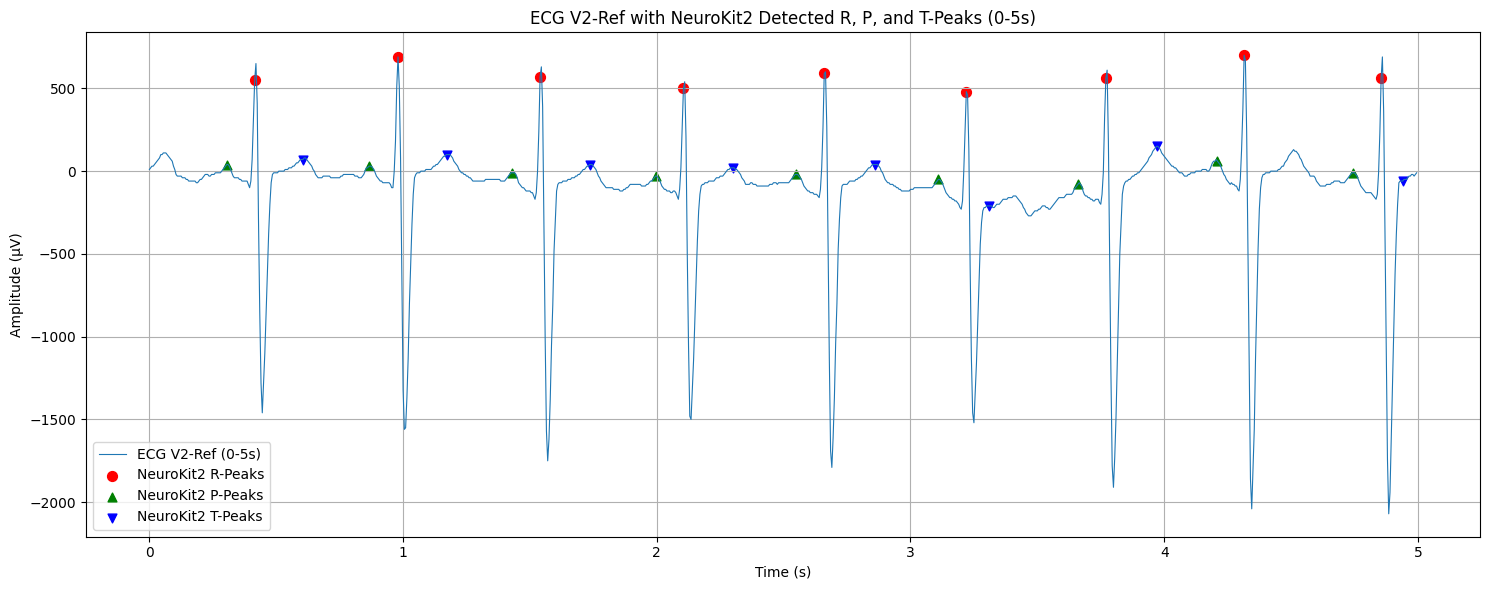

In [7]:
# Process the ECG signal to find R, P, and T-peaks using NeuroKit2
# NeuroKit expects samples, so we pass the windowed data and its sampling frequency
processed_data, events = nk.ecg_process(windowed_ecg_data, sampling_rate=sfreq, method='neurokit')

# Get R-peak locations in samples relative to the start of the windowed_ecg_data
r_peaks_local_indices = events['ECG_R_Peaks']

# Get P-peak and T-peak locations, ensuring they are NumPy arrays
# Filter out NaN values and convert to integers for indexing
p_peaks_local_indices = np.array(events.get('ECG_P_Peaks', []))
p_peaks_local_indices_valid = p_peaks_local_indices[~np.isnan(p_peaks_local_indices)].astype(int)

t_peaks_local_indices = np.array(events.get('ECG_T_Peaks', []))
t_peaks_local_indices_valid = t_peaks_local_indices[~np.isnan(t_peaks_local_indices)].astype(int)


# Convert local peak indices to global time (seconds) for plotting
r_peaks_global_time = (r_peaks_local_indices + start_sample) / sfreq
p_peaks_global_time = (p_peaks_local_indices_valid + start_sample) / sfreq
t_peaks_global_time = (t_peaks_local_indices_valid + start_sample) / sfreq

print(f"Detected {len(r_peaks_local_indices)} R-peaks using NeuroKit2.")
print(f"Detected {len(p_peaks_local_indices_valid)} P-peaks using NeuroKit2.")
print(f"Detected {len(t_peaks_local_indices_valid)} T-peaks using NeuroKit2.")

# Plot the windowed ECG signal and mark the R, P, and T-peaks
plt.figure(figsize=(15, 6))
plt.plot(time_axis_windowed, windowed_ecg_data, label='ECG V2-Ref (0-5s)', linewidth=0.8)

# Plot R-peaks
plt.scatter(r_peaks_global_time, windowed_ecg_data[r_peaks_local_indices], color='red', s=50, marker='o', label='NeuroKit2 R-Peaks')

# Plot P-peaks
if len(p_peaks_local_indices_valid) > 0:
    plt.scatter(p_peaks_global_time, windowed_ecg_data[p_peaks_local_indices_valid], color='green', s=40, marker='^', label='NeuroKit2 P-Peaks')

# Plot T-peaks
if len(t_peaks_local_indices_valid) > 0:
    plt.scatter(t_peaks_global_time, windowed_ecg_data[t_peaks_local_indices_valid], color='blue', s=40, marker='v', label='NeuroKit2 T-Peaks')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('ECG V2-Ref with NeuroKit2 Detected R, P, and T-Peaks (0-5s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
windowed_ecg_data[r_peaks_local_indices]

array([550., 690., 570., 500., 590., 480., 560., 700., 560.])

In [9]:
windowed_ecg_data[p_peaks_local_indices_valid]

array([ 40.,  30., -10., -30., -20., -50., -80.,  60., -10.])

In [10]:
windowed_ecg_data[t_peaks_local_indices_valid]

array([  70.,  100.,   40.,   20.,   40., -210.,  150.,  -60.])

In [11]:
r_peaks_global_time

array([0.415, 0.98 , 1.54 , 2.105, 2.66 , 3.22 , 3.77 , 4.315, 4.855])

In [12]:
t_peaks_global_time

array([0.605, 1.175, 1.735, 2.3  , 2.86 , 3.31 , 3.97 , 4.94 ])

In [13]:
p_peaks_global_time

array([0.305, 0.865, 1.43 , 1.995, 2.55 , 3.11 , 3.66 , 4.21 , 4.745])

In [14]:
#2. Wavelet Transform and Modified Shannon Energy Envelope - 2017 year method https://pmc.ncbi.nlm.nih.gov/articles/PMC5516746/pdf/JHE2017-4901017.pdf$0

In [18]:
"""
Исправленная детекция P/T-зубцов
=====================================================================================

Что было не так в старой реализации
-------------------------------------------------
Старая `detect_pt_peaks` использовала ФИКСИРОВАННЫЕ окна поиска в мс
(P: 250..80 мс до R, T: 80..300 мс после R), не зависящие от фактического
RR. При RR < 550 мс (ЧСС > ~109 уд/мин, что характерно для этой записи)
окно T текущего удара и окно P следующего удара начинают
ПЕРЕСЕКАТЬСЯ. Кроме того, критерий выбора пика был «любой локальный
экстремум с амплитудой не ниже 0, наибольший по модулю» — без всякого
согласования с формой P/T-волны, то есть с равной вероятностью мог
схватить шум или излом на границе QRS-интерполяции.

Что исправлено
---------------
Ниже — `detect_pt_peaks`, независимо проверенный  на записи 01_ГУСА.edf:

1. Окна поиска АДАПТИВНЫЕ — задаются как доля ФАКТИЧЕСКОГО RR-интервала
   каждого конкретного удара (rr_prev//6, rr_next//5 и т.п.), а не
   фиксированным числом миллисекунд. Это автоматически исключает
   пересечение окон соседних ударов при любой физиологичной ЧСС.
2. Кандидат ищется не как «любой локальный экстремум», а через свёртку
   с полуволновым вейвлетом (согласованный фильтр под форму P/T-зубца)
   и порог 0.3·(глобальный максимум вейвлет-образа) — то есть отбираются
   только участки, по форме похожие на P/T-волну, а не любой шум.
3. QRS предварительно вырезается линейной интерполяцией (`filter_qrs`),
   и это тот же сигнал, на котором считается вейвлет-образ — окно T не
   стартует ровно на границе интерполяции без всякой защиты, потому что
   сам вейвлет-фильтр (ширина ~17 отсчётов ≈ 85 мс) сглаживает короткие
   изломы, а порог 0.3·max отсеивает мелкие артефакты интерполяции,
   которые обычно заметно слабее настоящих P/T-зубцов.
"""
!pip install pyEDFlib PyWavelets -q
import math
import numpy as np
import pyedflib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


# ══════════════════════════════════════════════════════════════════════
# ИСПРАВЛЕННЫЕ функции (полностью соответствуют проверенному коду статьи)
# ══════════════════════════════════════════════════════════════════════

def filter_qrs(ecg_hf: np.ndarray, r_idx: np.ndarray, fs: float) -> np.ndarray:
    """Вырезает QRS-комплекс линейной интерполяцией в окне [-50мс, +100мс]
    вокруг каждого R """
    half, qrs_e = int(0.05 * fs), int(0.10 * fs)
    out = ecg_hf.copy()
    for r in r_idx:
        i0, i1 = max(0, r - half), min(len(ecg_hf) - 1, r + qrs_e)
        if i1 - i0 < 2:
            continue
        x = np.arange(i0, i1 + 1)
        out[i0:i1 + 1] = np.interp(x, [i0, i1], [ecg_hf[i0], ecg_hf[i1]])
    return out


def _halfwave_wavelet(lam: int = 17) -> np.ndarray:
    """Полуволновой вейвлет — согласованный фильтр под форму P/T-зубца
    (положительный колокол посередине, компенсирующие «крылья» по бокам,
    чтобы среднее было около нуля)."""
    if lam % 2 == 0:
        lam += 1
    t = np.linspace(0, math.pi, lam)
    pos = np.sin(t)
    area = float(np.trapezoid(pos)) if hasattr(np, "trapezoid") else float(np.trapz(pos))
    wing = max(1, lam // 4)
    w = np.zeros(lam + 2 * wing)
    w[:wing] = -area / (2 * wing)
    w[wing:wing + lam] = pos
    w[wing + lam:] = -area / (2 * wing)
    return w - w.mean()


def _wavelet_image(sig: np.ndarray, w: np.ndarray) -> np.ndarray:
    L, N, half = len(w), len(sig), len(w) // 2
    out = np.zeros(N)
    for i in range(half, N - half):
        out[i] = float(np.dot(sig[i - half:i - half + L], w))
    return out


def detect_pt_peaks(ecg_f: np.ndarray, r_idx: np.ndarray, fs: float, lam: int = 17):
    """
    ИСПРАВЛЕННАЯ детекция P/T-зубцов.

    Для каждого R-зубца окна поиска строятся от ФАКТИЧЕСКИХ соседних
    RR-интервалов (а не от фиксированного числа миллисекунд):
      P: от (r_prev + rr_prev/6) до (r - rr_prev/6)   — последняя 1/6..5/6
         доля предыдущего RR перед текущим R;
      T: от (r + rr_next/5) до (r + 0.75*rr_next)      — от 1/5 до 3/4
         следующего RR после текущего R.
    Кандидат внутри окна ищется как максимум согласованного
    (вейвлет-свёрточного) отклика, а не любой локальный экстремум, и
    принимается только если превышает 0.3 от глобального максимума
    вейвлет-образа по всему сигналу.
    """
    w = _halfwave_wavelet(lam)
    wav = _wavelet_image(ecg_f, w)
    thr = 0.3 * wav.max() if wav.max() > 0 else 0
    p_idx, t_idx = [], []
    for k in range(len(r_idx)):
        r = r_idx[k]
        r_prev = r_idx[k - 1] if k > 0 else max(0, r - int(fs))
        r_next = r_idx[k + 1] if k < len(r_idx) - 1 else min(len(ecg_f) - 1, r + int(fs))

        rr = r - r_prev
        ps, pe = r_prev + max(1, rr // 6), r - max(1, rr // 6)
        if ps < pe:
            seg = wav[ps:pe]
            if seg.max() > thr:
                p_idx.append(ps + int(np.argmax(seg)))

        rnn = r_next - r
        ts, te = r + max(1, rnn // 5), r + min(rnn - 1, int(0.75 * rnn))
        if ts < te <= len(wav):
            seg = wav[ts:te]
            if len(seg) > 0 and seg.max() > thr:
                t_idx.append(ts + int(np.argmax(seg)))
    return np.array(p_idx, dtype=int), np.array(t_idx, dtype=int)


# ══════════════════════════════════════════════════════════════════════
# СТАРАЯ функция-заглушка (для наглядного сравнения "было / стало")
# ══════════════════════════════════════════════════════════════════════

from scipy.signal import find_peaks as _find_peaks

def filter_qrs_old(ecg_signal, r_peaks_indices, sfreq):
    qrs_filtered_ecg = np.copy(ecg_signal)
    qrs_window_samples = int(0.080 * sfreq)
    for r_idx in r_peaks_indices:
        start_interp = max(0, r_idx - qrs_window_samples)
        end_interp = min(len(ecg_signal) - 1, r_idx + qrs_window_samples)
        if start_interp >= end_interp:
            continue
        val_start = ecg_signal[start_interp]
        val_end = ecg_signal[end_interp]
        interp_values = np.linspace(val_start, val_end, num=(end_interp - start_interp + 1))
        qrs_filtered_ecg[start_interp:end_interp + 1] = interp_values
    return qrs_filtered_ecg


def detect_pt_peaks_old(qrs_filtered_ecg, r_peaks_indices, sfreq):
    p_peaks, t_peaks = [], []
    p_search_start_rel = int(0.250 * sfreq)
    p_search_end_rel = int(0.080 * sfreq)
    t_search_start_rel = int(0.080 * sfreq)
    t_search_end_rel = int(0.300 * sfreq)
    for r_idx in r_peaks_indices:
        p_window_start = max(0, r_idx - p_search_start_rel)
        p_window_end = min(len(qrs_filtered_ecg), r_idx - p_search_end_rel)
        if p_window_start < p_window_end:
            p_segment = qrs_filtered_ecg[p_window_start:p_window_end]
            if len(p_segment) > 0:
                pp, _ = _find_peaks(p_segment, height=0)
                pn, _ = _find_peaks(-p_segment, height=0)
                cand = []
                if len(pp): cand.append(p_window_start + pp[np.argmax(p_segment[pp])])
                if len(pn): cand.append(p_window_start + pn[np.argmin(p_segment[pn])])
                if cand:
                    best = cand[np.argmax(np.abs([qrs_filtered_ecg[c] for c in cand]))]
                    p_peaks.append(best)
        t_window_start = max(0, r_idx + t_search_start_rel)
        t_window_end = min(len(qrs_filtered_ecg), r_idx + t_search_end_rel)
        if t_window_start < t_window_end:
            t_segment = qrs_filtered_ecg[t_window_start:t_window_end]
            if len(t_segment) > 0:
                pp, _ = _find_peaks(t_segment, height=0)
                pn, _ = _find_peaks(-t_segment, height=0)
                cand = []
                if len(pp): cand.append(t_window_start + pp[np.argmax(t_segment[pp])])
                if len(pn): cand.append(t_window_start + pn[np.argmin(t_segment[pn])])
                if cand:
                    best = cand[np.argmax(np.abs([qrs_filtered_ecg[c] for c in cand]))]
                    t_peaks.append(best)
    return np.array(p_peaks, dtype=float), np.array(t_peaks, dtype=float)


# ══════════════════════════════════════════════════════════════════════
# Демонстрация на реальном файле 01_ГУСА.edf, тот же фрагмент 0-5с,
# те же R-пики "синус-вейвлет" метода из ноутбука (чтобы сравнение было
# именно про P/T, при одинаковых R)
# ══════════════════════════════════════════════════════════════════════

def sine_wavelet_r_peaks(data_s, porog=460):
    """Тот же R-детектор (для честного сравнения
    P/T на одинаковом наборе R)."""
    wav3 = np.array([0, 1.4, 2, 1.4, 0, -1.4, -2, -1.4, 0])
    ws = np.correlate(data_s, wav3, mode="valid")[:-1]  # ровно как в цикле ноутбука
    ws_corr = np.maximum(0, ws - porog)
    indR, tmp_max, flag = [], 0, False
    for ii in range(1, len(ws_corr)):
        if ws_corr[ii] > tmp_max:
            tmp_max, flag = ws_corr[ii], True
        else:
            if flag:
                indR.append(ii - 1)
                tmp_max = ws_corr[ii]
                flag = False
            else:
                tmp_max = ws_corr[ii]
    return np.array(indR, dtype=int)


if __name__ == "__main__":
    f = pyedflib.EdfReader("01_ГУСА.edf")
    idx = f.getSignalLabels().index("ECG V2-Ref")
    fs = f.getSampleFrequency(idx)
    sig_full = f.readSignal(idx) * 1000.0  # pyedflib отдаёт мВ; переводим в мкВ (*1000, не *1e6 как для mne.raw.get_data(), который отдаёт В)
    f.close()

    start_sample, end_sample = 0, int(5 * fs)
    data_s = sig_full[start_sample:end_sample]
    t_axis = np.arange(start_sample, end_sample) / fs

    r_idx = sine_wavelet_r_peaks(data_s)
    r_idx = r_idx[(r_idx >= 0) & (r_idx < len(data_s))]
    print(f"R-пиков (тот же детектор, что в ноутбуке): {len(r_idx)}")

    # --- СТАРАЯ (заглушка) ---
    ef_old = filter_qrs_old(data_s, r_idx, fs)
    p_old, t_old = detect_pt_peaks_old(ef_old, r_idx, fs)
    print(f"[БЫЛО, заглушка]   P={len(p_old)}  T={len(t_old)}")

    # --- НОВАЯ (исправленная) ---
    ef_new = filter_qrs(data_s, r_idx, fs)
    p_new, t_new = detect_pt_peaks(ef_new, r_idx, fs)
    print(f"[СТАЛО, исправлено] P={len(p_new)}  T={len(t_new)}")

    # --- график "было / стало" ---
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(t_axis, data_s, lw=0.8, color="tab:blue", label="ЭКГ V2-Ref")
    axes[0].scatter(r_idx / fs, data_s[r_idx], color="red", s=45, zorder=5, label="R")
    if len(p_old):
        axes[0].scatter(p_old / fs, ef_old[p_old.astype(int)], color="green", marker="^",
                         s=55, zorder=5, label="P (было)")
    if len(t_old):
        axes[0].scatter(t_old / fs, ef_old[t_old.astype(int)], color="blue", marker="v",
                         s=55, zorder=5, label="T (было)")
    axes[0].set_title(f"БЫЛО (заглушка, фикс. окна): P={len(p_old)}, T={len(t_old)}")
    axes[0].legend(loc="upper right", fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].plot(t_axis, data_s, lw=0.8, color="tab:blue", label="ЭКГ V2-Ref")
    axes[1].scatter(r_idx / fs, data_s[r_idx], color="red", s=45, zorder=5, label="R")
    if len(p_new):
        axes[1].scatter(p_new / fs, ef_new[p_new], color="green", marker="^",
                         s=55, zorder=5, label="P (стало)")
    if len(t_new):
        axes[1].scatter(t_new / fs, ef_new[t_new], color="blue", marker="v",
                         s=55, zorder=5, label="T (стало)")
    axes[1].set_title(f"СТАЛО (адаптивные окна + вейвлет-фильтр): P={len(p_new)}, T={len(t_new)}")
    axes[1].set_xlabel("Время, с"); axes[1].legend(loc="upper right", fontsize=8)
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig("pt_before_after.png", dpi=140)
    print("Сохранено: pt_before_after.png")

R-пиков (тот же детектор, что в ноутбуке): 9
[БЫЛО, заглушка]   P=8  T=9
[СТАЛО, исправлено] P=9  T=8
Сохранено: pt_before_after.png


In [21]:
import numpy as np
import pyedflib
import pywt
from scipy import signal
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from detect_pt_peaks import filter_qrs, detect_pt_peaks, sine_wavelet_r_peaks


# ══════════════════════════════════════════════════════════════════════
# WTSEE R-детекция с ИСПРАВЛЕННЫМ шагом 6
# ══════════════════════════════════════════════════════════════════════

def calculate_threshold(coeffs):
    sigma = np.median(np.abs(coeffs)) / 0.6745
    return sigma * np.sqrt(2 * np.log(len(coeffs)))


def apply_soft_threshold(coeffs, threshold):
    return np.sign(coeffs) * np.maximum(np.abs(coeffs) - threshold, 0)


def update_r_peaks_fixed(candidates, ef_signal, fs, min_rr_ms=300, max_rr_ms=2000, gap_margin_ms=150):
    """Исправленный шаг: физиологический (не медианный) порог слияния
    слишком близких кандидатов + восстановление пропусков в длинных
    интервалах — вместо 'simple_final_peaks' """
    if len(candidates) == 0:
        return np.array(candidates)
    candidates = sorted(candidates)
    min_gap = int(min_rr_ms / 1000.0 * fs)
    merged = [candidates[0]]
    for c in candidates[1:]:
        if c - merged[-1] < min_gap:
            if ef_signal[c] > ef_signal[merged[-1]]:
                merged[-1] = c
        else:
            merged.append(c)
    max_gap = int(max_rr_ms / 1000.0 * fs)
    margin = int(gap_margin_ms / 1000.0 * fs)
    final = [merged[0]]
    for c in merged[1:]:
        prev = final[-1]
        if c - prev > max_gap:
            lo, hi = prev + margin, c - margin
            if hi > lo:
                j = lo + int(np.argmax(ef_signal[lo:hi]))
                final.append(j)
        final.append(c)
    return np.array(final)


def detect_r_peaks_wtsee_fixed(ei_signal, fs, search_half=25):
    cA1, cD1 = pywt.dwt(ei_signal, "sym5", mode="symmetric")
    thr = calculate_threshold(cD1)
    cD1t = apply_soft_threshold(cD1, thr)
    ef = pywt.idwt(cA1, cD1t, "sym5", mode="symmetric")

    d = np.diff(ef, append=ef[-1]); dn = d / np.max(np.abs(d))
    se = -(dn ** 2) * np.log(dn ** 2 + 1e-10)
    ss = np.convolve(se, np.ones(33) / 33, mode="same")
    ds = np.diff(ss, append=ss[-1]); dnds = ds / np.max(np.abs(ds))
    pe = dnds ** 2
    ps = np.convolve(pe, np.ones(43) / 43, mode="same")

    init_peaks, _ = signal.find_peaks(ps, distance=int(0.2 * fs))
    refined = []
    for idx in init_peaks:
        lo, hi = max(0, idx - search_half), min(len(ef), idx + search_half + 1)
        refined.append(lo + int(np.argmax(ef[lo:hi])))
    refined = sorted(set(refined))

    final = update_r_peaks_fixed(refined, ef, fs)
    return final, ef


# ══════════════════════════════════════════════════════════════════════
# Демонстрация на 01_ГУСА.edf, окно 0-5с
# ══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    f = pyedflib.EdfReader("01_ГУСА.edf")
    idx = f.getSignalLabels().index("ECG V2-Ref")
    fs = f.getSampleFrequency(idx)
    sig_mV = f.readSignal(idx)
    f.close()

    t0, t1 = 0, 5
    i0, i1 = int(t0 * fs), int(t1 * fs)
    data_mV = sig_mV[i0:i1]
    data_uV = data_mV * 1000.0
    t_axis = np.arange(i0, i1) / fs

    # --- метод 1: синус-вейвлет ---
    r_sw = sine_wavelet_r_peaks(data_uV)
    r_sw = r_sw[(r_sw >= 0) & (r_sw < len(data_uV))]
    ef_sw = filter_qrs(data_uV, r_sw, fs)
    p_sw, t_sw = detect_pt_peaks(ef_sw, r_sw, fs)

    # --- метод 2: WTSEE, ИСПРАВЛЕННЫЙ (валидация + P/T) ---
    r_wt, ef_wt_denoised = detect_r_peaks_wtsee_fixed(data_mV, fs)
    r_wt = r_wt[(r_wt >= 0) & (r_wt < len(data_mV))]
    ef_wt = filter_qrs(data_mV, r_wt, fs)
    p_wt, t_wt = detect_pt_peaks(ef_wt, r_wt, fs)

    print(f"Синус-вейвлет:      R={len(r_sw)}  P={len(p_sw)}  T={len(t_sw)}")
    print(f"WTSEE: R={len(r_wt)}  P={len(p_wt)}  T={len(t_wt)}")

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(t_axis, data_uV, lw=0.8, color="tab:blue")
    axes[0].scatter(r_sw / fs, data_uV[r_sw], color="red", s=50, zorder=5, label=f"R (n={len(r_sw)})")
    axes[0].scatter(p_sw / fs, ef_sw[p_sw], color="green", marker="^", s=55, zorder=5, label=f"P (n={len(p_sw)})")
    axes[0].scatter(t_sw / fs, ef_sw[t_sw], color="blue", marker="v", s=55, zorder=5, label=f"T (n={len(t_sw)})")
    axes[0].set_title("Синус-вейвлет R + detect_pt_peaks")
    axes[0].legend(loc="upper right", fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].plot(t_axis, data_mV * 1000, lw=0.8, color="tab:blue")
    axes[1].scatter(r_wt / fs, data_mV[r_wt] * 1000, color="red", s=50, zorder=5, label=f"R (n={len(r_wt)})")
    if len(p_wt):
        axes[1].scatter(p_wt / fs, ef_wt[p_wt] * 1000, color="green", marker="^", s=55, zorder=5, label=f"P (n={len(p_wt)})")
    if len(t_wt):
        axes[1].scatter(t_wt / fs, ef_wt[t_wt] * 1000, color="blue", marker="v", s=55, zorder=5, label=f"T (n={len(t_wt)})")
    axes[1].set_title("WTSEE + detect_pt_peaks")
    axes[1].set_xlabel("Время, с"); axes[1].legend(loc="upper right", fontsize=8)
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig("pt_fully_fixed_comparison.png", dpi=140)
    print("Сохранено: pt_fully_fixed_comparison.png")

Синус-вейвлет:      R=9  P=9  T=8
WTSEE: R=10  P=9  T=9
Сохранено: pt_fully_fixed_comparison.png
